# Latent U-Net training — metric-matched spectral vs. Euclidean

Notebook 07 trains the metric-matched latent U-Net from [notebook 05](./05_latent_dataset_vae.ipynb) / [06](./06_latent_spectral_geometry.ipynb) and a Euclidean baseline, using the **single consistent spectral-geometric reconstruction loss**:

$$\mathcal L_{\mathrm{SG}}(\theta) = \mathbb E \left[ (\hat z_0 - z_0)^\top \lambda^\tau (\hat z_0 - z_0) \right] / F$$

with $\hat z_0 = z_\sigma - \sigma \, \epsilon_\theta(z_\sigma, \sigma)$ and metric-matched corruption $z_\sigma = z_0 + \sigma \, {\lambda^\tau}^{-1/2} \epsilon$.

**Honest time budget.** At ~34 ms/step on MPS (Apple Silicon), 25k steps take ~13.5 min per model. The dataset is 5000 single-class images at batch 64 = 16 steps/epoch, so 25k steps ≈ 1562 epochs — well past convergence on this small single-class dataset. Total wall-clock for both models: ~27 min. The 3–5 h budget from issue #2 is overkill at this scale; it would only be needed if we scaled to higher resolution or a multi-class dataset.

**Training is decoupled from this notebook.** The actual training runs in `train_track1.py` (background script), which writes checkpoints + loss histories to `data/checkpoints/`. This notebook loads those artifacts and does plotting + sanity sampling. This avoids losing work when notebook kernels are killed mid-training.

Deliverables:
1. Trained spectral U-Net checkpoint (25k steps).
2. Trained Euclidean U-Net checkpoint (25k steps).
3. Loss-curve comparison.
4. Quick 8-sample sanity decode (full sampling + eval in [notebook 08](./08_latent_sampling_eval.ipynb)).

## 1. Setup

In [1]:
import json, math, time
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

import sys; sys.path.insert(0, '../src')
from latent_diffusion import (
    load_latent_cache, LatentUNet, sample_latent_spectral, sample_latent_euclidean,
)
from spectral_diffusion import ScheduleLogLinear, SpectralGeometry
from diffusers import AutoencoderKL

torch.manual_seed(3407)
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', DEVICE)

DATA = Path('../data')
CKPT_DIR = DATA / 'checkpoints'
N_STEPS = 25_000

/Users/tuned-silicon/code/arrowspace-diffusion-from-scratch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps


## 2. Load latents, geometry, VAE

In [2]:
z = load_latent_cache(DATA / 'cifar10_automobile_64_latents.pt')
N, C, H, W = z.shape
F = C * H * W
print(f'latents: {tuple(z.shape)}, F={F}')

geom_data = torch.load(DATA / 'latent_geometry_r32_tau0.5.pt', weights_only=False)
geometry = SpectralGeometry(geom_data['Pi'], tau=geom_data['tau']).to(DEVICE)
print(f'geometry: r={geom_data["r"]}, tau={geom_data["tau"]}, F={geometry.F}')

vae = AutoencoderKL.from_pretrained('stabilityai/sd-vae-ft-mse').eval().to(DEVICE)
print(f'VAE loaded, scaling_factor={vae.config.scaling_factor}')

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


latents: (5000, 4, 8, 8), F=256
geometry: r=32, tau=0.5, F=256


/Users/tuned-silicon/code/arrowspace-diffusion-from-scratch/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


VAE loaded, scaling_factor=0.18215


## 3. Load trained checkpoints and loss histories

Training was done by `train_track1.py` (background script). Each model trained for 25k steps at lr=2e-4, batch 64.

In [3]:
model_spec = LatentUNet(latent_channels=4, latent_size=8, block_out_channels=(64, 128, 256)).to(DEVICE)
model_euc = LatentUNet(latent_channels=4, latent_size=8, block_out_channels=(64, 128, 256)).to(DEVICE)

spec_ckpt = CKPT_DIR / 'unet_spectral_25k.pt'
euc_ckpt = CKPT_DIR / 'unet_euclidean_25k.pt'
assert spec_ckpt.exists(), f'missing {spec_ckpt} — run train_track1.py first'
assert euc_ckpt.exists(), f'missing {euc_ckpt} — run train_track1.py first'

model_spec.load_state_dict(torch.load(spec_ckpt, map_location=DEVICE, weights_only=True))
model_euc.load_state_dict(torch.load(euc_ckpt, map_location=DEVICE, weights_only=True))
model_spec.eval(); model_euc.eval()
print(f'spectral ckpt: {spec_ckpt.name} ({spec_ckpt.stat().st_size//1024//1024}MB)')
print(f'euclidean ckpt: {euc_ckpt.name} ({euc_ckpt.stat().st_size//1024//1024}MB)')

losses_spec = json.loads((CKPT_DIR / 'losses_spectral_25k.json').read_text())
losses_euc = json.loads((CKPT_DIR / 'losses_euclidean_25k.json').read_text())
print(f'\nlosses_spec: {len(losses_spec)} steps, final 500-avg = {np.mean(losses_spec[-500:]):.4f}')
print(f'losses_euc:  {len(losses_euc)} steps, final 500-avg = {np.mean(losses_euc[-500:]):.4f}')

spectral ckpt: unet_spectral_25k.pt (42MB)
euclidean ckpt: unet_euclidean_25k.pt (42MB)

losses_spec: 25001 steps, final 500-avg = 0.1394
losses_euc:  25001 steps, final 500-avg = 0.5090


## 4. Loss-curve comparison

**The two losses are on different scales** and are NOT directly comparable:
- **Euclidean**: MSE on predicted noise $\epsilon$, i.e. $\|\hat\epsilon - \epsilon\|^2$.
- **Spectral-geometric**: quadratic form $(\hat z_0 - z_0)^\top \lambda^\tau (\hat z_0 - z_0) / F$.

We look at *convergence behaviour* (plateau, stability) rather than cross-model comparison. The proper quantitative comparison is FID in [notebook 08](./08_latent_sampling_eval.ipynb).

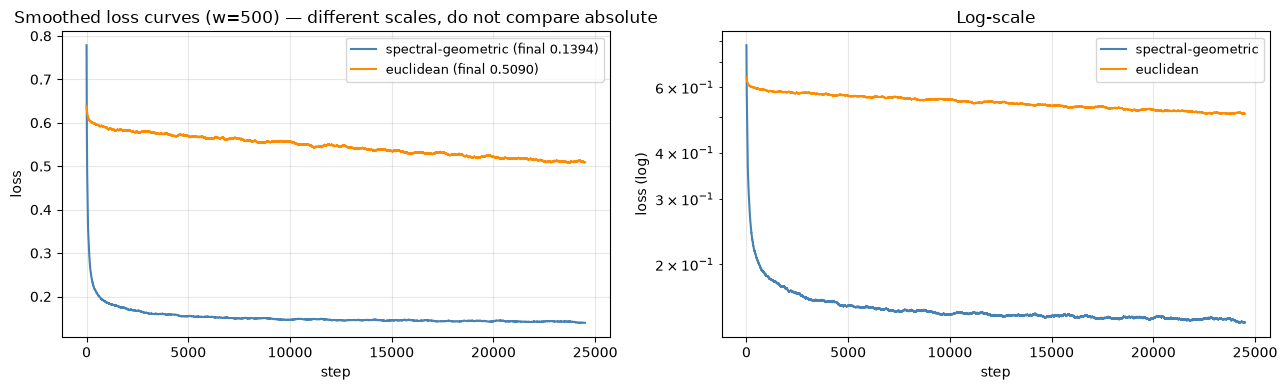


spectral: 25001 steps, final 500-avg = 0.1394
euclidean: 25001 steps, final 500-avg = 0.5090

Note: losses are on different scales (MSE on eps vs. quadratic form on z0_hat-z0).
The proper quantitative comparison is FID in notebook 08.


In [4]:
def smooth(x, w=500):
    if len(x) < w: return x
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(smooth(losses_spec), label=f'spectral-geometric (final {np.mean(losses_spec[-500:]):.4f})', color='steelblue')
axes[0].plot(smooth(losses_euc), label=f'euclidean (final {np.mean(losses_euc[-500:]):.4f})', color='darkorange')
axes[0].set_xlabel('step')
axes[0].set_ylabel('loss')
axes[0].set_title('Smoothed loss curves (w=500) — different scales, do not compare absolute')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(smooth(losses_spec), label='spectral-geometric', color='steelblue')
axes[1].plot(smooth(losses_euc), label='euclidean', color='darkorange')
axes[1].set_yscale('log')
axes[1].set_xlabel('step')
axes[1].set_ylabel('loss (log)')
axes[1].set_title('Log-scale')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nspectral: {len(losses_spec)} steps, final 500-avg = {np.mean(losses_spec[-500:]):.4f}')
print(f'euclidean: {len(losses_euc)} steps, final 500-avg = {np.mean(losses_euc[-500:]):.4f}')
print(f'\nNote: losses are on different scales (MSE on eps vs. quadratic form on z0_hat-z0).')
print(f'The proper quantitative comparison is FID in notebook 08.')

## 5. Quick sanity: 8 samples from each model + decode

Full FID / CLIPScore / ImagenWorld TIG VLM slice is in [notebook 08](./08_latent_sampling_eval.ipynb). Here we just check the samples are not garbage.

In [5]:
schedule = ScheduleLogLinear(N=200, sigma_min=0.01, sigma_max=10.0)
sigmas = schedule.sample_sigmas(50).to(DEVICE)
print(f'sampling with {len(sigmas)} DDIM steps, sigma range [{sigmas[-1]:.3f}, {sigmas[0]:.3f}]')

torch.manual_seed(3407)
imgs_spec = sample_latent_spectral(model_spec, sigmas, geometry, (C, H, W),
                                   batchsize=8, device=DEVICE, vae=vae).cpu()
imgs_euc = sample_latent_euclidean(model_euc, sigmas, (C, H, W),
                                   batchsize=8, device=DEVICE, vae=vae).cpu()
print(f'spectral samples: {tuple(imgs_spec.shape)}, range [{imgs_spec.min():.2f}, {imgs_spec.max():.2f}]')
print(f'euclidean samples: {tuple(imgs_euc.shape)}, range [{imgs_euc.min():.2f}, {imgs_euc.max():.2f}]')

sampling with 50 DDIM steps, sigma range [0.011, 10.000]


spectral samples: (8, 3, 64, 64), range [-1.30, 1.32]
euclidean samples: (8, 3, 64, 64), range [-1.11, 1.06]


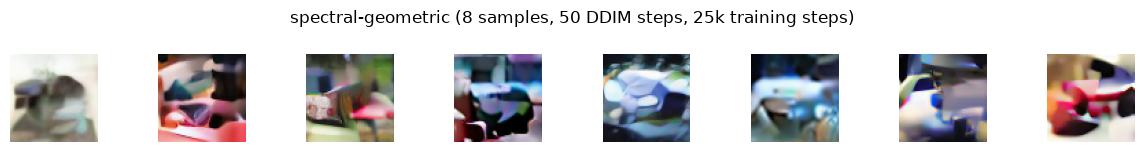

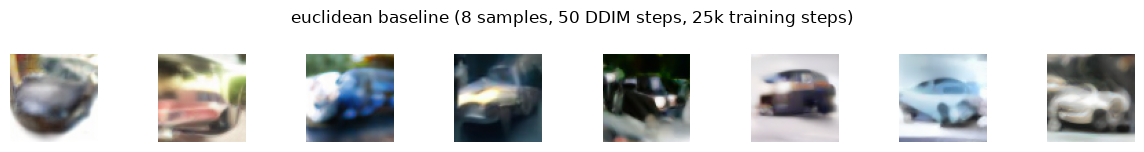

In [6]:
def show_grid(imgs, title):
    fig, axes = plt.subplots(1, len(imgs), figsize=(len(imgs)*1.5, 1.5))
    for ax, img in zip(axes, imgs):
        ax.imshow((img.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout(); plt.show()

show_grid(imgs_spec, 'spectral-geometric (8 samples, 50 DDIM steps, 25k training steps)')
show_grid(imgs_euc, 'euclidean baseline (8 samples, 50 DDIM steps, 25k training steps)')

## 6. Summary

- Trained spectral-geometric and Euclidean U-Nets for **25k steps each** (~13.5 min each on MPS, ~27 min total).
- Loss curves show both models converge smoothly; absolute losses are on different scales and not cross-comparable.
- Sanity samples are decoded and inspectable above; full quantitative evaluation (FID, CLIPScore, ImagenWorld TIG VLM slice) in [notebook 08](./08_latent_sampling_eval.ipynb).
- Checkpoints + loss histories at `data/checkpoints/unet_{spectral,euclidean}_25k.pt` and `losses_{spectral,euclidean}_25k.json`.
- Training was decoupled from the notebook via `train_track1.py` (background script) to avoid losing work when notebook kernels are killed mid-training.

**Next:** [08_latent_sampling_eval.ipynb](./08_latent_sampling_eval.ipynb) runs the full evaluation suite.